# Commonwealth Protocol Mathematical Curves
This notebook visualizes the core bonding curves used in the Commonwealth Protocol.
For each curve, it plots:
1. The pure mathematical curve (Price vs Supply)
2. How price changes during buying over time (with Vault Compounding)
3. How price changes during selling over time


In [1]:
import sys
import os
from decimal import Decimal as D
import matplotlib.pyplot as plt

# Add project root to sys.path so we can import sim.core
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
project_root = os.path.abspath(os.path.join(script_dir, '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from sim.core import (
    User, Vault, LP, CurveType, CURVE_NAMES,
    DISABLE_VIRTUAL_LIQUIDITY, STRICT_MODE
)

def D_to_f(d_val):
    return float(d_val)


In [2]:
def simulate_curve(curve_type, title, poly_exponent=None, buy_iters=50, buy_amount=D(500), sell_iters=50, sell_percent=D('0.02')):
    print(f"--- Simulating {title} ---")
    
    fig, axs = plt.subplots(1, 3, figsize=(24, 6))
    
    # 1. Plot Pure Implementation (Price vs Supply)
    supplies = [D(i * 1000) for i in range(101)]  # 0 to 100k tokens
    prices = []
    
    if curve_type == CurveType.CONSTANT_PRODUCT:
        initial_token = D(10_000)
        k = initial_token * D(10_000)
        for s in supplies:
            # Scale s by Exposure factor (1000) for plotting
            effective_s = s / D(1000)
            if initial_token - effective_s <= 0:
                prices.append(None)
            else:
                x_prime = initial_token - effective_s
                y_prime = k / x_prime
                prices.append(y_prime / x_prime)
    else:
        from sim.core import _CURVE_DISPATCH, _poly_price
        if curve_type == CurveType.POLYNOMIAL:
            for s in supplies:
                prices.append(_poly_price(s, exponent=poly_exponent))
        else:
            _, spot_fn = _CURVE_DISPATCH[curve_type]
            for s in supplies:
                prices.append(spot_fn(s))
                
    valid_supplies = [s for s, p in zip(supplies, prices) if p is not None]
    valid_prices = [p for p in prices if p is not None]
    
    axs[0].plot([D_to_f(s) for s in valid_supplies], [D_to_f(p) for p in valid_prices], color='blue')
    axs[0].set_title(f"{title} - Pure Implementation")
    axs[0].set_xlabel("Supply")
    axs[0].set_ylabel("Price (USDC)")
    axs[0].grid(True)
    
    # 2. Simulate Buying over time with Compound
    vault = Vault()
    lp = LP(vault, curve_type, yield_impacts_price=True, lp_impacts_price=False, poly_exponent=poly_exponent)
    user = User("Alice", usd=D(1_000_000))
    
    buy_prices = []
    for _ in range(buy_iters):
        lp.buy(user, buy_amount)
        vault.compound(1) # 1 day passes
        buy_prices.append(lp.price)
        
    axs[1].plot(range(buy_iters), [D_to_f(p) for p in buy_prices], color='green', marker='o', markersize=3)
    axs[1].set_title(f"{title} - Price during Buying")
    axs[1].set_xlabel("Buy Iteration (1 iter = 1 day, 500 USDC)")
    axs[1].set_ylabel("Price (USDC)")
    axs[1].grid(True)
    
    # 3. Simulate Selling over time
    sell_prices = []
    for _ in range(sell_iters):
        tokens_to_sell = user.balance_token * sell_percent
        if tokens_to_sell > 0:
            lp.sell(user, tokens_to_sell)
        sell_prices.append(lp.price)
        
    axs[2].plot(range(sell_iters), [D_to_f(p) for p in sell_prices], color='red', marker='x', markersize=3)
    axs[2].set_title(f"{title} - Price during Selling")
    axs[2].set_xlabel("Sell Iteration (2% of balance)")
    axs[2].set_ylabel("Price (USDC)")
    axs[2].grid(True)
    
    
    
    plt.tight_layout()
    plt.show()


--- Simulating Constant Product ---


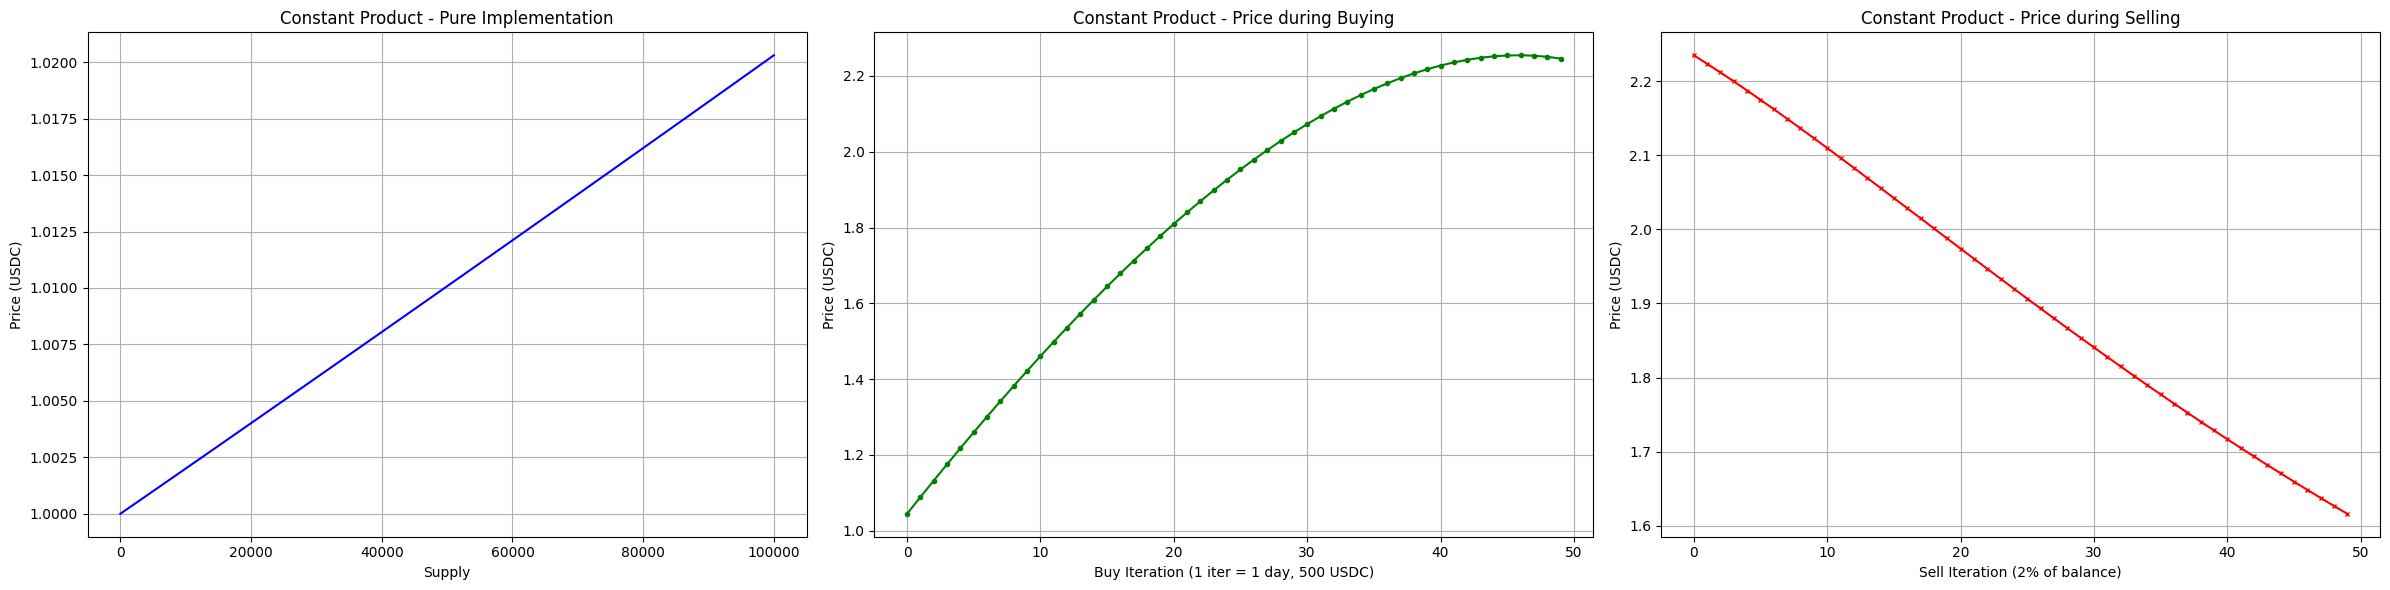

In [3]:
simulate_curve(CurveType.CONSTANT_PRODUCT, "Constant Product")

--- Simulating Exponential Curve ---


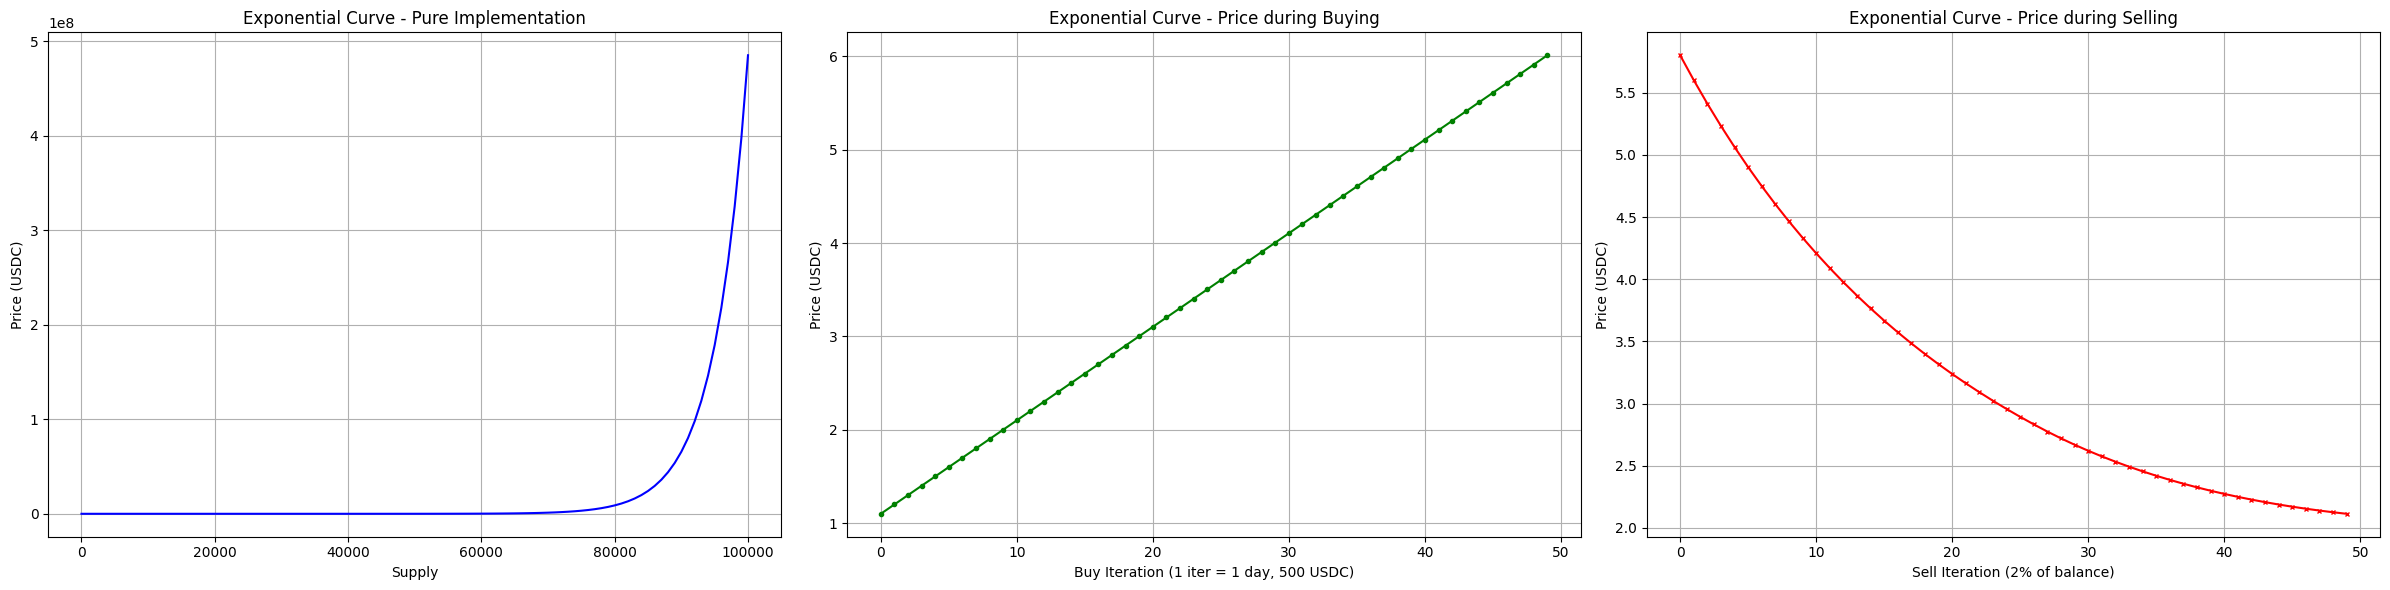

In [4]:
simulate_curve(CurveType.EXPONENTIAL, "Exponential Curve")

--- Simulating Sigmoid Curve ---


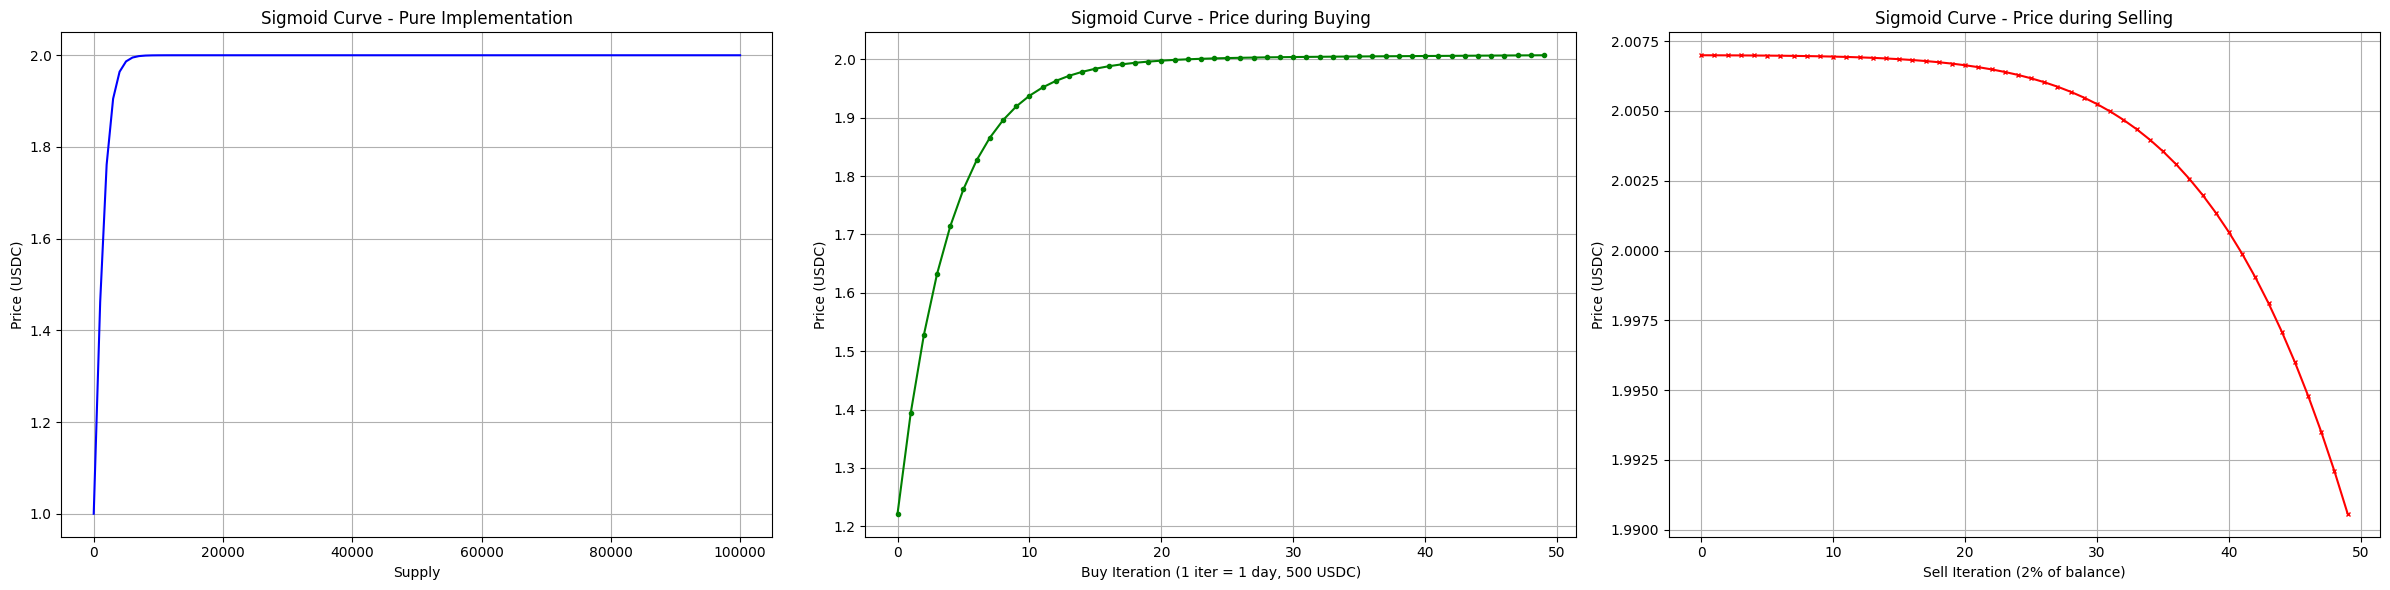

In [5]:
simulate_curve(CurveType.SIGMOID, "Sigmoid Curve")

--- Simulating Logarithmic Curve ---


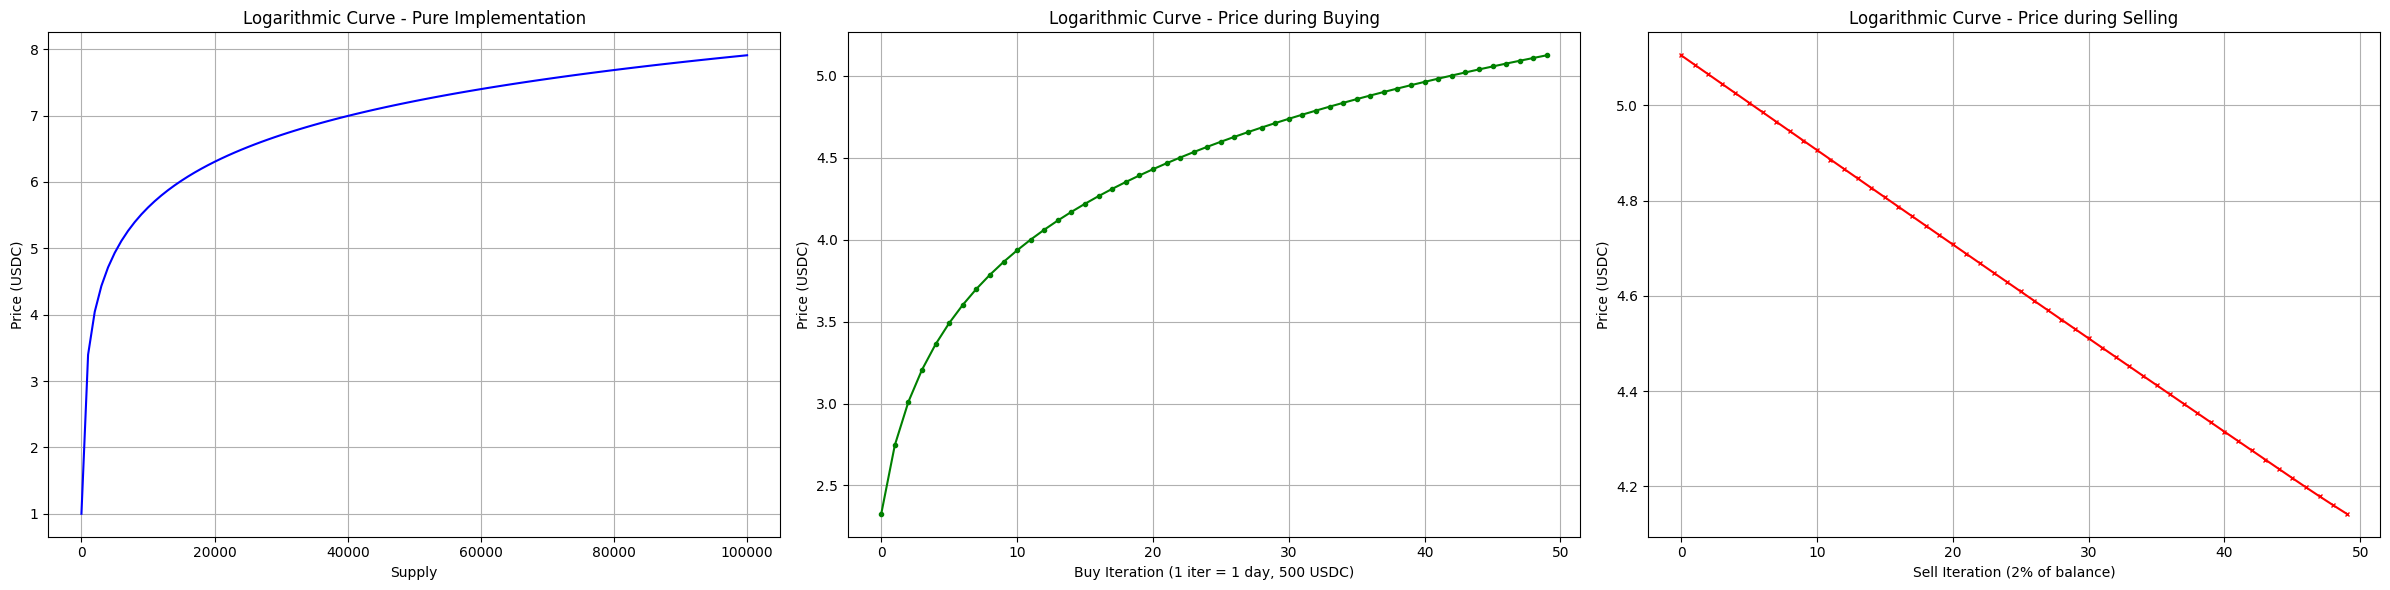

In [6]:
simulate_curve(CurveType.LOGARITHMIC, "Logarithmic Curve")

--- Simulating Polynomial Curve (n=1.5) ---


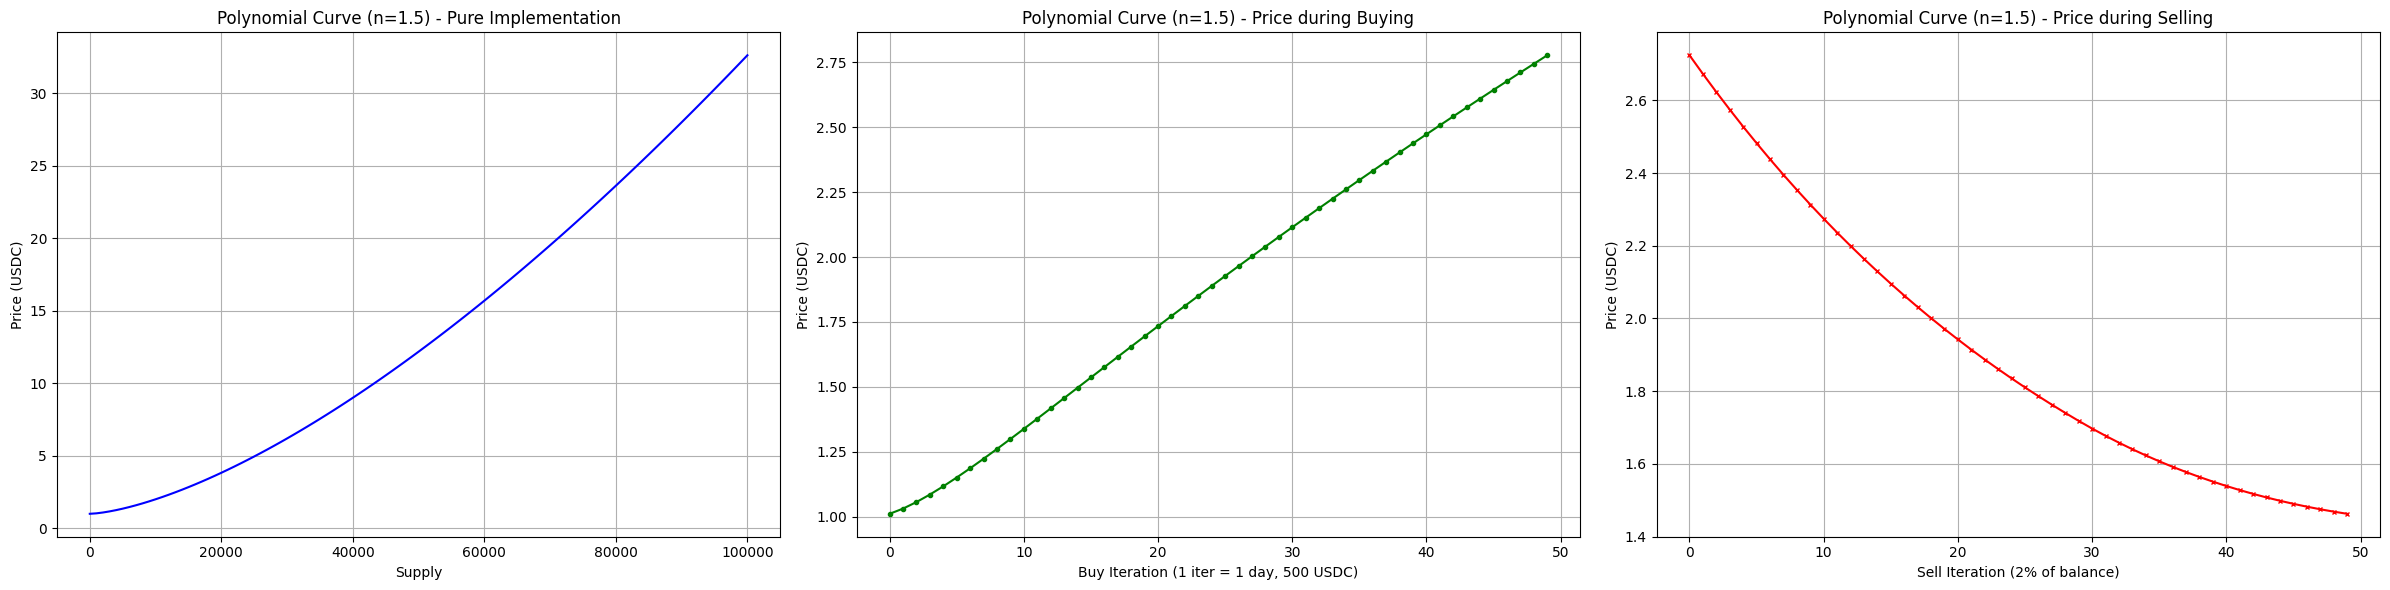

In [7]:
simulate_curve(CurveType.POLYNOMIAL, "Polynomial Curve (n=1.5)", poly_exponent=D("1.5"))

--- Simulating Polynomial Curve (n=1.2) ---


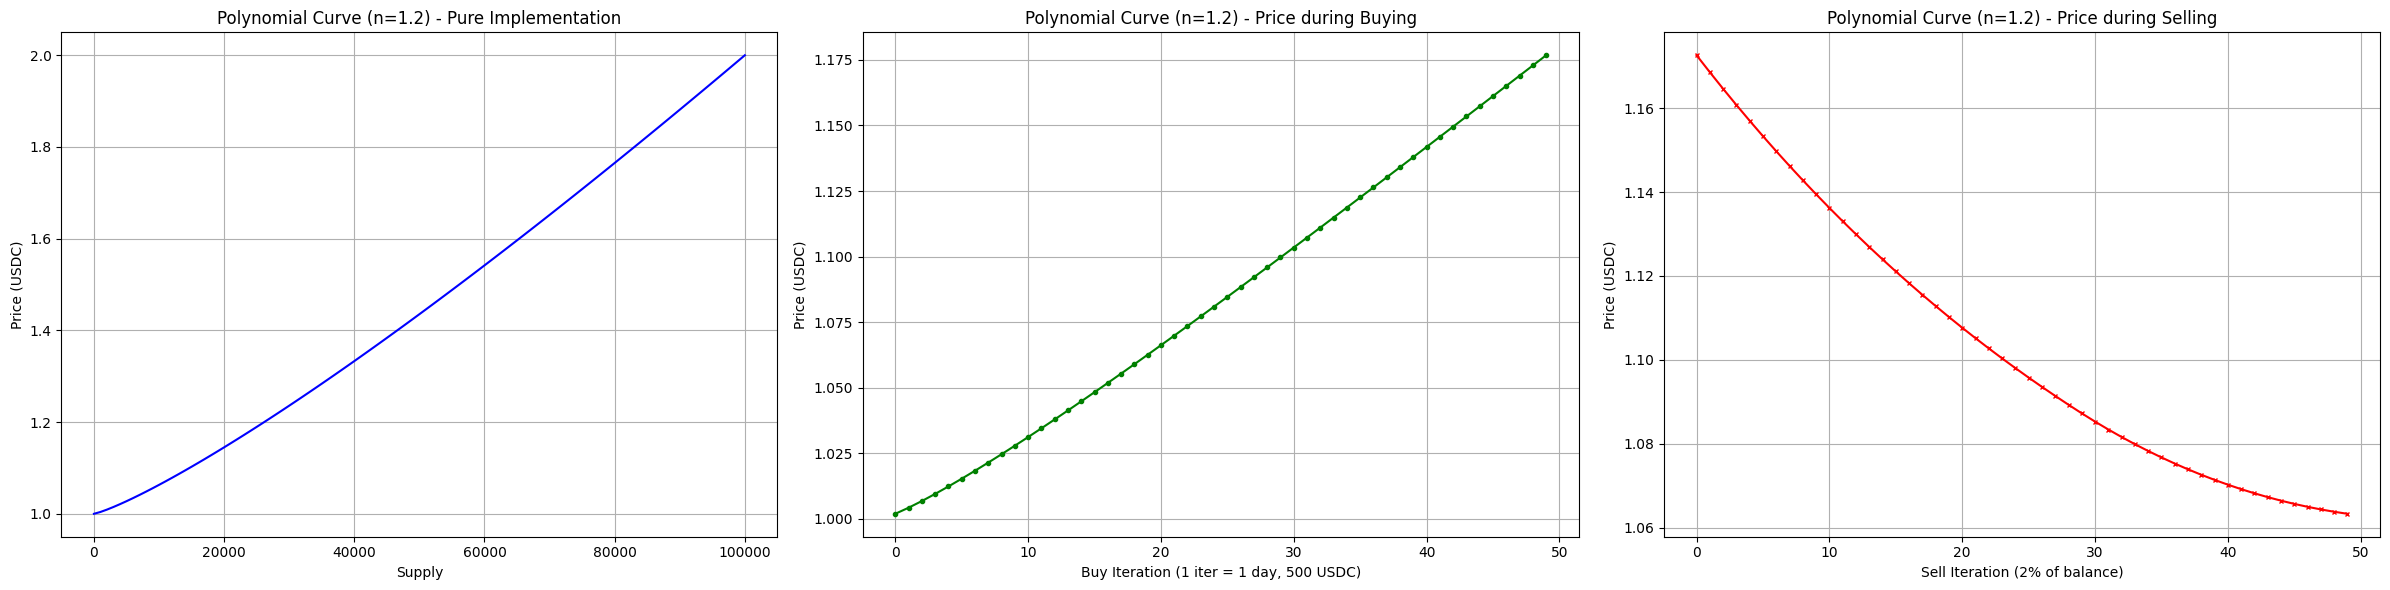

In [8]:
simulate_curve(CurveType.POLYNOMIAL, "Polynomial Curve (n=1.2)", poly_exponent=D('1.2'))